In [2]:
import numpy as np
import random
import copy

In [3]:
class Sudoku:
    def __init__(self, grid):
        """grid: lista de listas 9x9 con enteros del 0 al 9 (0 = vacío)."""
        if len(grid) != 9 or any(len(row) != 9 for row in grid):
            raise ValueError("El tablero debe ser 9x9.")
        self.grid = grid

    def __repr__(self):
        lines = []
        for i, row in enumerate(self.grid):
            # Convertir cada valor en string, usando '.' para los vacíos
            row_str = ""
            for j, val in enumerate(row):
                sep = " "
                if j % 3 == 0 and j != 0:
                    sep = " | "
                row_str += sep + (str(val) if val != 0 else ".")
            lines.append(row_str.strip())

            # Línea horizontal después de cada bloque de 3 filas
            if (i + 1) % 3 == 0 and i != 8:
                lines.append("-" * 21)

        return "\n".join(lines)

    def get_row(self, r):
        return self.grid[r]

    def get_col(self, c):
        return [self.grid[i][c] for i in range(9)]

    def get_box(self, box_row, box_col):
        """Devuelve los 9 elementos de una subcuadrícula 3x3"""
        start_r, start_c = box_row * 3, box_col * 3
        return [
            self.grid[r][c]
            for r in range(start_r, start_r + 3)
            for c in range(start_c, start_c + 3)
        ]

    def is_valid(self):
        """Verifica que el Sudoku esté resuelto correctamente."""
        nums = set(range(1, 10))
        for i in range(9):
            if set(self.get_row(i)) != nums:
                return False
            if set(self.get_col(i)) != nums:
                return False
        for br in range(3):
            for bc in range(3):
                if set(self.get_box(br, bc)) != nums:
                    return False
        return True
    def get_vector(self):
        vector = np.array(self.grid).flatten()
        return vector

class SudokuGenerator:
    """Genera sudokus válidos y resolubles (opcionalmente con huecos)."""

    @staticmethod
    def generate_full():
        """Genera una solución completa de Sudoku usando backtracking."""
        def is_valid(num, r, c, grid):
            r0 = r - r % 3
            c0 = c - c % 3
            row_ok = num not in grid[r]
            col_ok = num not in [grid[i][c] for i in range(9)]
            box_ok = num not in [
                grid[r0 + i][c0 + j]
                for i in range(3)
                for j in range(3)
            ]
            return row_ok and col_ok and box_ok

        def solve(grid):
            for r in range(9):
                for c in range(9):
                    if grid[r][c] == 0:
                        for num in random.sample(range(1, 10), 9):
                            if is_valid(num, r, c, grid):
                                grid[r][c] = num
                                if solve(grid):
                                    return True
                                grid[r][c] = 0
                        return False
            return True

        grid = [[0] * 9 for _ in range(9)]
        solve(grid)
        return Sudoku(grid)

    @staticmethod
    def generate_puzzle(holes=40):
        """Genera un Sudoku con una cantidad de huecos (0 = vacío)."""
        sudoku = SudokuGenerator.generate_full()
        grid = copy.deepcopy(sudoku.grid)
        positions = [(r, c) for r in range(9) for c in range(9)]
        random.shuffle(positions)
        for i in range(holes):
            r, c = positions[i]
            grid[r][c] = 0
        return Sudoku(grid)


In [4]:
# Crear un Sudoku con huecos
puzzle = SudokuGenerator.generate_puzzle(holes=40)
print("\nSudoku con huecos:")
print(puzzle)


Sudoku con huecos:
7 3 4 | . . . | 8 . 2
. . 9 | . 3 2 | . 6 4
6 . 5 | 7 . 8 | 9 . 3
---------------------
9 . 1 | . 5 4 | 3 . .
. 8 7 | . 6 . | . 4 1
4 . . | . . 1 | 6 . .
---------------------
. . 8 | . . . | 4 9 .
5 9 . | . . 7 | . 3 6
. 4 6 | . . 5 | . 8 .


In [84]:
initial_mask = puzzle.get_vector()

In [85]:
def randomize_init(initital_mask):
    child = np.random.randint(1, 10, size=initial_mask.size)
    child[initial_mask != 0] = initial_mask[initial_mask != 0]
    return child

In [86]:
def generate_childs(initital_mask, n:int):
    return np.array([randomize_init(initial_mask) for i in range(n)])

In [87]:
def fitness(candidate):
        """Evalúa qué tan válido es el Sudoku (menos errores = mejor)."""
        # Aplicamos máscara para respetar celdas fijas
        grid = candidate.reshape((9, 9))

        score = 0
        for i in range(9):
            row = grid[i, :]
            col = grid[:, i]
            box = grid[(i//3)*3:(i//3)*3+3, (i%3)*3:(i%3)*3+3].flatten()

            score += len(set(row))
            score += len(set(col))
            score += len(set(box))

        # Máximo posible = 9*3*9 = 243 si no hay repeticiones
        return score

In [88]:
def cruza(individuals):
    parent1, parent2 = individuals
    mask = np.random.randint(0, 2, size=parent1.size)  # 0 or 1
    
    # Create children
    child1 = np.where(mask == 1, parent1, parent2)
    child2 = np.where(mask == 1, parent2, parent1)
    
    return child1, child2


In [89]:
def mutate(child):
    random_prob = 0.1
    random_values = np.random.randint(1, 10, size=child.size)

    random_choices = np.random.random(size=child.size)

    mutated_child = np.where(random_choices>random_prob, child, random_values)
    mutated_child[initial_mask != 0] = initial_mask[initial_mask != 0]
    return mutated_child

In [108]:
def evaluate_scores(individuals):
    individuals_scores = np.array([fitness(indiv) for indiv in individuals])
    normalized_scores = individuals_scores / np.sum(individuals_scores) # Normalizamos valores
    return normalized_scores, individuals_scores

In [109]:
def genetic_algorithm(parents, elite_num = 2):

    total_individuos = parents.shape[0]
    total_elite = elite_num

    canditad_cruces = int((total_individuos-total_elite) / 2)

    parent_scores, _ = evaluate_scores(parents)
    
    idx = np.argpartition(parent_scores, -elite_num)[-elite_num:]      # Unsorted top-n indices
    idx = idx[np.argsort(parent_scores[idx])[::-1]]    # Sort them descending by value

    elite_childs = parents[idx].copy() # Seleccion por elitismo

    total_selected_childs = []

    for _ in range(canditad_cruces):
        selected_childs = random.choices(parents, k= 2, weights= parent_scores)
        new_children = cruza(selected_childs)
        total_selected_childs.extend(new_children)
    final_childs = []

    for child in total_selected_childs:
        final_childs.append(mutate(child.copy()))

    for elite_child in elite_childs:
        final_childs.append(elite_child.copy())

    return np.array(final_childs)

In [110]:
from tqdm import tqdm

In [118]:
max_values = []
median = []

number_iterations = 1000
number_childs = 1000
number_elite = 200

childs = generate_childs(initial_mask, number_childs)


iterations = list(range(number_iterations))
max_values = []
median = []

for i in tqdm(iterations, desc="Running Genetic Algorithm"):
    childs = genetic_algorithm(childs.copy(), number_elite)
    _, childs_scores = evaluate_scores(childs)
    
    max_values.append(childs_scores.max())
    median.append(childs_scores.mean())
    


Running Genetic Algorithm:   0%|          | 0/1000 [00:00<?, ?it/s]

Running Genetic Algorithm: 100%|██████████| 1000/1000 [02:33<00:00,  6.50it/s]


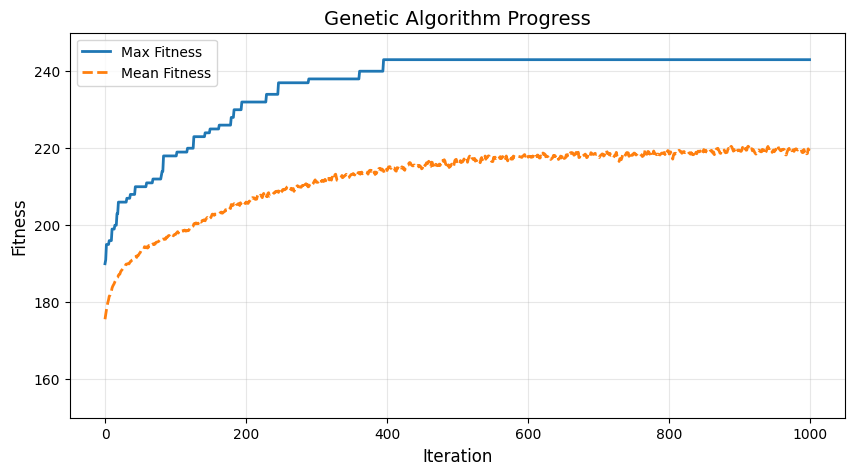

In [124]:
import matplotlib.pyplot as plt

# Assuming you already have these lists filled:
# iterations, max_values, median

plt.figure(figsize=(10, 5))

# Plot max fitness
plt.plot(iterations, max_values, label="Max Fitness", linewidth=2)

# Plot median fitness
plt.plot(iterations, median, label="Mean Fitness", linestyle="--", linewidth=2)

# Add labels and legend
plt.title("Genetic Algorithm Progress", fontsize=14)
plt.xlabel("Iteration", fontsize=12)
plt.ylabel("Fitness", fontsize=12)
plt.ylim([150,250])
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()


In [125]:
childs_scores.max()

np.int64(243)

In [126]:
solution = childs[np.argmax(childs_scores)]

In [127]:
solution = Sudoku(solution.reshape((9,9)))

In [128]:
solution.is_valid()

True

In [129]:
solution

7 3 4 | 6 1 9 | 8 5 2
8 1 9 | 5 3 2 | 7 6 4
6 2 5 | 7 4 8 | 9 1 3
---------------------
9 6 1 | 2 5 4 | 3 7 8
2 8 7 | 9 6 3 | 5 4 1
4 5 3 | 8 7 1 | 6 2 9
---------------------
1 7 8 | 3 2 6 | 4 9 5
5 9 2 | 4 8 7 | 1 3 6
3 4 6 | 1 9 5 | 2 8 7